# Wine Quality Analysis
## Phân tích và Phân loại Dữ liệu Rượu Vang

Bài tập yêu cầu:
1. Tải dữ liệu và phân tích thống kê
2. Trực quan hóa dữ liệu (Dimensionality Reduction)
3. Huấn luyện mô hình máy học và so sánh (K-Fold CV)
4. Gom cụm (Clustering) với K-Means và DBSCAN

## 1. Tải dữ liệu và phân tích thống kê

  Tất cả libraries đã import thành công
  Dữ liệu được tải thành công

Kích thước dữ liệu:
  - Số mẫu (rows): 1599
  - Số đặc trưng (columns): 12

=== Dữ liệu mẫu (5 dòng đầu) ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  

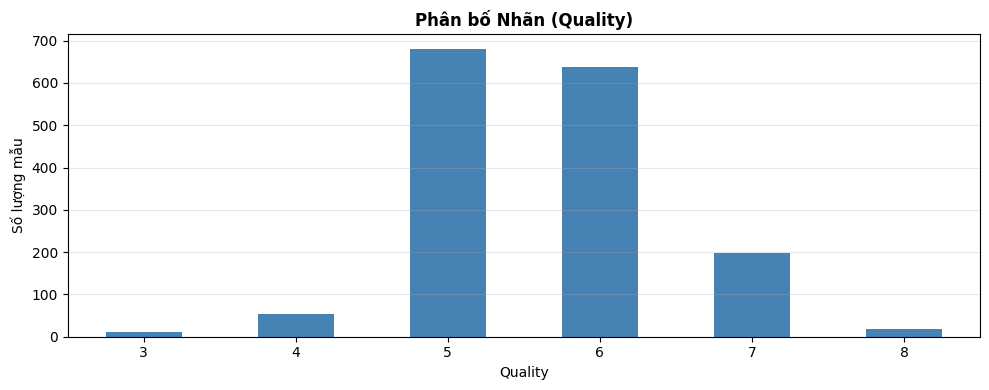


=== Thống kê của các cột có giá trị số ===
                         Min       Max     Mean      Std
fixed acidity         4.6000   15.9000   8.3196   1.7411
volatile acidity      0.1200    1.5800   0.5278   0.1791
citric acid           0.0000    1.0000   0.2710   0.1948
residual sugar        0.9000   15.5000   2.5388   1.4099
chlorides             0.0120    0.6110   0.0875   0.0471
free sulfur dioxide   1.0000   72.0000  15.8749  10.4602
total sulfur dioxide  6.0000  289.0000  46.4678  32.8953
density               0.9901    1.0037   0.9967   0.0019
pH                    2.7400    4.0100   3.3111   0.1544
sulphates             0.3300    2.0000   0.6581   0.1695
alcohol               8.4000   14.9000  10.4230   1.0657
quality               3.0000    8.0000   5.6360   0.8076

=== Kiểm tra Missing Values ===
  Không có missing values


In [143]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("  Tất cả libraries đã import thành công")

# Tải dữ liệu
# Đọc file CSV
df = pd.read_csv('data/winequality-red.csv')

print(f"  Dữ liệu được tải thành công")
print(f"\nKích thước dữ liệu:")
print(f"  - Số mẫu (rows): {df.shape[0]}")
print(f"  - Số đặc trưng (columns): {df.shape[1]}")

# Phân tích thống kê cơ bản
# a. Hiển thị 5 dòng đầu tiên
print("\n=== Dữ liệu mẫu (5 dòng đầu) ===")
print(df.head())

# b. Kiểu dữ liệu của các thuộc tính
print("\n=== Kiểu dữ liệu của các cột ===")
print(df.dtypes)

# c. Số lượng thực thể của các giá trị nhãn (quality)
print("\n=== Phân bố nhãn (Quality) ===")
label_counts = df['quality'].value_counts().sort_index()
print(label_counts)
print(f"\nTổng số mẫu: {label_counts.sum()}")

# Visualize label distribution
plt.figure(figsize=(10, 4))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Phân bố Nhãn (Quality)', fontsize=12, fontweight='bold')
plt.xlabel('Quality')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# d. Giá trị lớn nhất, bé nhất, và trung bình của các cột số
print("\n=== Thống kê của các cột có giá trị số ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats_df = pd.DataFrame({
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max(),
    'Mean': df[numeric_cols].mean(),
    'Std': df[numeric_cols].std()
})

print(stats_df.round(4))

# Kiểm tra missing values
print("\n=== Kiểm tra Missing Values ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  Không có missing values")
else:
    print(missing[missing > 0])

## 2. Trực Quan Hóa Dữ Liệu (2D Visualization)

In [144]:
# Tách features và labels
X = df.drop('quality', axis=1)
y = df['quality']

print(f"  Features: {X.shape[1]} đặc trưng")
print(f"  Labels: {len(np.unique(y))} lớp")
print(f"\nCác đặc trưng: {list(X.columns)}")

  Features: 11 đặc trưng
  Labels: 6 lớp

Các đặc trưng: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [145]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("  Dữ liệu được chuẩn hóa (StandardScaler)")

  Dữ liệu được chuẩn hóa (StandardScaler)


In [146]:
# Giảm chiều xuống 2D bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\n  Giảm chiều từ {X_scaled.shape[1]} xuống 2D")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Tổng variance giải thích: {sum(pca.explained_variance_ratio_):.4f}")


  Giảm chiều từ 11 xuống 2D
Explained variance ratio: [0.28173931 0.1750827 ]
Tổng variance giải thích: 0.4568


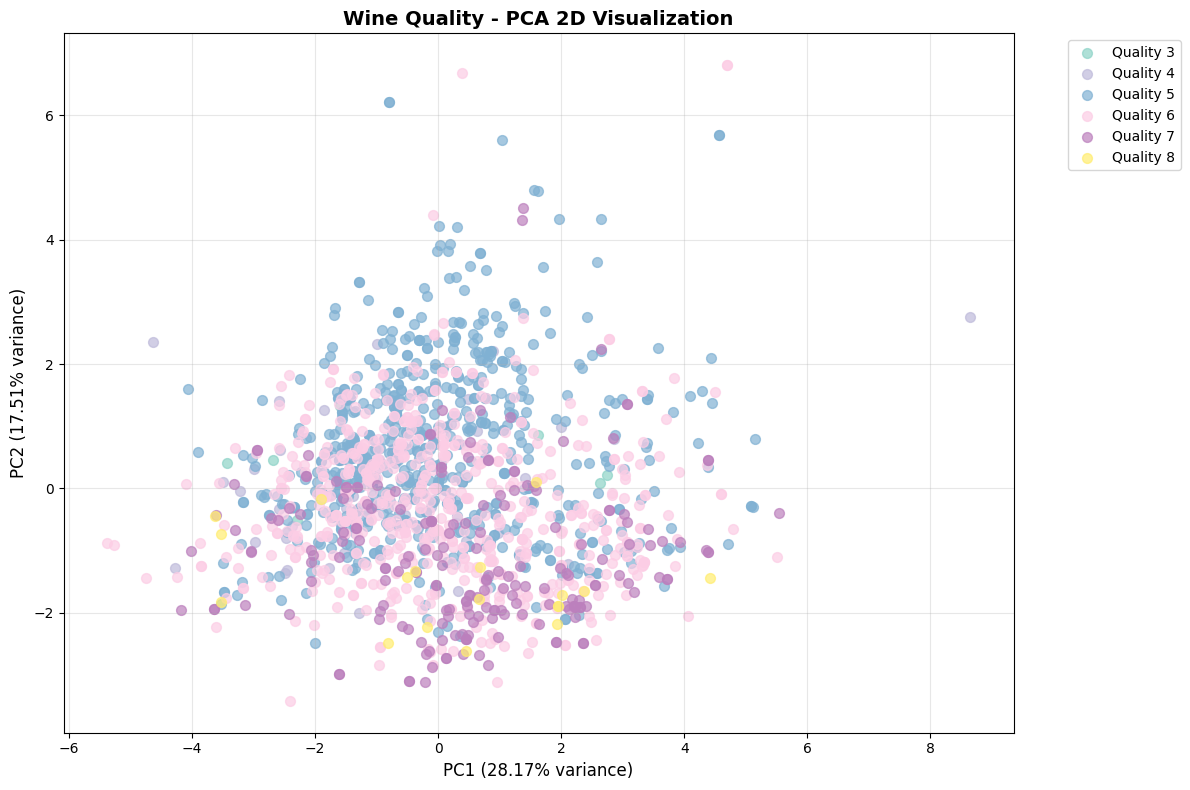

In [147]:
# Vẽ biểu đồ 2D với các màu khác nhau cho các nhãn
plt.figure(figsize=(12, 8))

# Định nghĩa colormap
colors = plt.cm.Set3(np.linspace(0, 1, len(np.unique(y))))

# Vẽ từng nhãn với màu khác nhau
for i, quality in enumerate(sorted(np.unique(y))):
    mask = y == quality
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Quality {quality}', 
               alpha=0.7, s=50, color=colors[i])

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Wine Quality - PCA 2D Visualization', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Huấn Luyện Mô Hình Máy Học

### 3.1 Chuẩn bị dữ liệu

In [6]:
# Sử dụng dữ liệu đã chuẩn hóa
X_train = X_scaled
y_train = y

print(f"  Training set size: {X_train.shape[0]} mẫu, {X_train.shape[1]} đặc trưng")
print(f"  Classes: {sorted(np.unique(y_train))}")

  Training set size: 1599 mẫu, 11 đặc trưng
  Classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


### 3.2 K-Nearest Neighbors (KNN)

#### 3.2.1 Định nghĩa Tham số

In [7]:
# Model 1: K-Nearest Neighbors (KNN)
print("="*60)
print("MODEL 1: K-NEAREST NEIGHBORS (KNN)")
print("="*60)

# Định nghĩa tám số để tìm kiếm
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],      # Số lượng hàng xóm
    'weights': ['uniform', 'distance'],   # Loại trọng số
    'metric': ['euclidean', 'manhattan']  # Metryka khoảng cách
}

print("\nTham số cần tìm kiếm:")
for param, values in knn_params.items():
    print(f"  - {param}: {values}")

knn = KNeighborsClassifier()
print(f"\n  Model KNN được khởi tạo")

MODEL 1: K-NEAREST NEIGHBORS (KNN)

Tham số cần tìm kiếm:
  - n_neighbors: [3, 5, 7, 9, 11]
  - weights: ['uniform', 'distance']
  - metric: ['euclidean', 'manhattan']

  Model KNN được khởi tạo


#### 3.2.2 Tinh Chỉnh Tham Số (Hyperparameter Tuning)

In [8]:
# GridSearchCV cho KNN
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

print("\nTinh chỉnh tham số KNN với GridSearchCV (K-Fold, k=10)...\n")

grid_search_knn = GridSearchCV(
    knn, knn_params,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train, y_train)

# In ra chi tiết quá trình tinh chỉnh từng lần
print("\n" + "="*100)
print("CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ KNN")
print("="*100)

results = grid_search_knn.cv_results_
for i in range(len(results['params'])):
    params_str = ", ".join([f"{k}={v}" for k, v in results['params'][i].items()])
    print(f"Lần {i+1:2d}: {params_str} | F1={results['mean_test_score'][i]:.4f}")

best_knn = grid_search_knn.best_estimator_
best_params_knn = grid_search_knn.best_params_
best_score_knn = grid_search_knn.best_score_

print(f"\n{'='*60}")
print(f"  KNN - Kết quả tối ưu")
print(f"{'='*60}")
print(f"Best F1-Score (Validation): {best_score_knn:.4f}")
print(f"\nTham số tối ưu:")
for param, value in best_params_knn.items():
    print(f"  - {param}: {value}")


Tinh chỉnh tham số KNN với GridSearchCV (K-Fold, k=10)...

Fitting 10 folds for each of 20 candidates, totalling 200 fits

CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ KNN
Lần  1: metric=euclidean, n_neighbors=3, weights=uniform | F1=0.5766
Lần  2: metric=euclidean, n_neighbors=3, weights=distance | F1=0.6574
Lần  3: metric=euclidean, n_neighbors=5, weights=uniform | F1=0.5706
Lần  4: metric=euclidean, n_neighbors=5, weights=distance | F1=0.6597
Lần  5: metric=euclidean, n_neighbors=7, weights=uniform | F1=0.5568
Lần  6: metric=euclidean, n_neighbors=7, weights=distance | F1=0.6612
Lần  7: metric=euclidean, n_neighbors=9, weights=uniform | F1=0.5653
Lần  8: metric=euclidean, n_neighbors=9, weights=distance | F1=0.6698
Lần  9: metric=euclidean, n_neighbors=11, weights=uniform | F1=0.5689
Lần 10: metric=euclidean, n_neighbors=11, weights=distance | F1=0.6696
Lần 11: metric=manhattan, n_neighbors=3, weights=uniform | F1=0.5645
Lần 12: metric=manhattan, n_neighbors=3, weights=distance | F1=0.657

#### 3.2.3 Đánh Giá Mô Hình

In [9]:
# Đánh giá KNN với K-Fold CV
print("\nĐánh giá KNN với K-Fold Cross Validation (k=10)...\n")

knn_f1_scores = cross_val_score(
    best_knn, X_train, y_train,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1
)

knn_cv_results = {
    'f1_scores': knn_f1_scores,
    'mean_f1': knn_f1_scores.mean(),
    'std_f1': knn_f1_scores.std()
}

print(f"F1-Scores cho mỗi fold: {np.round(knn_f1_scores, 4)}")
print(f"\n{'='*60}")
print(f"KNN - Kết quả Cross Validation")
print(f"{'='*60}")
print(f"Mean F1-Score: {knn_cv_results['mean_f1']:.4f}")
print(f"Std F1-Score:  {knn_cv_results['std_f1']:.4f}")
print(f"Min F1-Score:  {knn_cv_results['f1_scores'].min():.4f}")
print(f"Max F1-Score:  {knn_cv_results['f1_scores'].max():.4f}")


Đánh giá KNN với K-Fold Cross Validation (k=10)...

F1-Scores cho mỗi fold: [0.6379 0.6586 0.6692 0.6366 0.7114 0.6543 0.694  0.6918 0.687  0.7162]

KNN - Kết quả Cross Validation
Mean F1-Score: 0.6757
Std F1-Score:  0.0272
Min F1-Score:  0.6366
Max F1-Score:  0.7162


### 3.3 Random Forest (RF)

#### 3.3.1 Định nghĩa Tham số

In [10]:
# Model 2: Random Forest
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST (RF)")
print("="*60)

# Định nghĩa tham số để tìm kiếm
rf_params = {
    'n_estimators': [50, 100, 200],           # Số lượng cây quyết định
    'max_depth': [5, 10, 15, None],           # Độ sâu tối đa của cây
    'min_samples_split': [2, 5],              # Số mẫu tối thiểu để chia
    'min_samples_leaf': [1, 2]                # Số mẫu tối thiểu ở lá
}

print("\nTham số cần tìm kiếm:")
for param, values in rf_params.items():
    print(f"  - {param}: {values}")

rf = RandomForestClassifier(random_state=42)
print(f"\n  Model Random Forest được khởi tạo")


MODEL 2: RANDOM FOREST (RF)

Tham số cần tìm kiếm:
  - n_estimators: [50, 100, 200]
  - max_depth: [5, 10, 15, None]
  - min_samples_split: [2, 5]
  - min_samples_leaf: [1, 2]

  Model Random Forest được khởi tạo


#### 3.3.2 Tinh Chỉnh Tham Số (Hyperparameter Tuning)

In [11]:
# GridSearchCV cho Random Forest
print("\nTinh chỉnh tham số Random Forest với GridSearchCV (K-Fold, k=10)...\n")

grid_search_rf = GridSearchCV(
    rf, rf_params,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

# In ra chi tiết quá trình tinh chỉnh từng lần
print("\n" + "="*100)
print("CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ RANDOM FOREST")
print("="*100)

results_rf = grid_search_rf.cv_results_
for i in range(len(results_rf['params'])):
    params_str = ", ".join([f"{k}={v}" for k, v in results_rf['params'][i].items()])
    print(f"Lần {i+1:2d}: {params_str} | F1={results_rf['mean_test_score'][i]:.4f}")

best_rf = grid_search_rf.best_estimator_
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"\n{'='*60}")
print(f"  Random Forest - Kết quả tối ưu")
print(f"{'='*60}")
print(f"Best F1-Score (Validation): {best_score_rf:.4f}")
print(f"\nTham số tối ưu:")
for param, value in best_params_rf.items():
    print(f"  - {param}: {value}")


Tinh chỉnh tham số Random Forest với GridSearchCV (K-Fold, k=10)...

Fitting 10 folds for each of 48 candidates, totalling 480 fits

CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ RANDOM FOREST
Lần  1: max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50 | F1=0.5888
Lần  2: max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100 | F1=0.5882
Lần  3: max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200 | F1=0.5878
Lần  4: max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=50 | F1=0.5926
Lần  5: max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100 | F1=0.5882
Lần  6: max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=200 | F1=0.5854
Lần  7: max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=50 | F1=0.5860
Lần  8: max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100 | F1=0.5855
Lần  9: max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200 | F1=0.586

#### 3.3.3 Đánh Giá Mô Hình

In [12]:
# Đánh giá Random Forest với K-Fold CV
print("\nĐánh giá Random Forest với K-Fold Cross Validation (k=10)...\n")

rf_f1_scores = cross_val_score(
    best_rf, X_train, y_train,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1
)

rf_cv_results = {
    'f1_scores': rf_f1_scores,
    'mean_f1': rf_f1_scores.mean(),
    'std_f1': rf_f1_scores.std()
}

print(f"F1-Scores cho mỗi fold: {np.round(rf_f1_scores, 4)}")
print(f"\n{'='*60}")
print(f"Random Forest - Kết quả Cross Validation")
print(f"{'='*60}")
print(f"Mean F1-Score: {rf_cv_results['mean_f1']:.4f}")
print(f"Std F1-Score:  {rf_cv_results['std_f1']:.4f}")
print(f"Min F1-Score:  {rf_cv_results['f1_scores'].min():.4f}")
print(f"Max F1-Score:  {rf_cv_results['f1_scores'].max():.4f}")


Đánh giá Random Forest với K-Fold Cross Validation (k=10)...

F1-Scores cho mỗi fold: [0.666  0.6895 0.7087 0.6774 0.7104 0.6741 0.7028 0.6998 0.7672 0.7282]

Random Forest - Kết quả Cross Validation
Mean F1-Score: 0.7024
Std F1-Score:  0.0281
Min F1-Score:  0.6660
Max F1-Score:  0.7672


### 3.4 Support Vector Machine (SVM)

#### 3.4.1 Định nghĩa Tham số

In [13]:
# Model 3: Support Vector Machine (SVM)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

# Định nghĩa tham số để tìm kiếm
svm_params = {
    'C': [0.1, 1, 10],                   # Tham số regularization
    'kernel': ['rbf', 'poly'],           # Loại kernel
    'gamma': ['scale', 'auto']           # Tham số gamma
}

print("\nTham số cần tìm kiếm:")
for param, values in svm_params.items():
    print(f"  - {param}: {values}")

svm = SVC(random_state=42)
print(f"\n  Model SVM được khởi tạo")


MODEL 3: SUPPORT VECTOR MACHINE (SVM)

Tham số cần tìm kiếm:
  - C: [0.1, 1, 10]
  - kernel: ['rbf', 'poly']
  - gamma: ['scale', 'auto']

  Model SVM được khởi tạo


#### 3.4.2 Tinh Chỉnh Tham Số (Hyperparameter Tuning)

In [14]:
# GridSearchCV cho SVM
print("\nTinh chỉnh tham số SVM với GridSearchCV (K-Fold, k=10)...\n")

grid_search_svm = GridSearchCV(
    svm, svm_params,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

# In ra chi tiết quá trình tinh chỉnh từng lần
print("\n" + "="*100)
print("CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ SVM")
print("="*100)

results_svm = grid_search_svm.cv_results_
for i in range(len(results_svm['params'])):
    params_str = ", ".join([f"{k}={v}" for k, v in results_svm['params'][i].items()])
    print(f"Lần {i+1:2d}: {params_str} | F1={results_svm['mean_test_score'][i]:.4f}")

best_svm = grid_search_svm.best_estimator_
best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"\n{'='*60}")
print(f"  Support Vector Machine - Kết quả tối ưu")
print(f"{'='*60}")
print(f"Best F1-Score (Validation): {best_score_svm:.4f}")
print(f"\nTham số tối ưu:")
for param, value in best_params_svm.items():
    print(f"  - {param}: {value}")


Tinh chỉnh tham số SVM với GridSearchCV (K-Fold, k=10)...

Fitting 10 folds for each of 12 candidates, totalling 120 fits

CHI TIẾT QUÁ TRÌNH TINH CHỈNH THAM SỐ SVM
Lần  1: C=0.1, gamma=scale, kernel=rbf | F1=0.5317
Lần  2: C=0.1, gamma=scale, kernel=poly | F1=0.4990
Lần  3: C=0.1, gamma=auto, kernel=rbf | F1=0.5311
Lần  4: C=0.1, gamma=auto, kernel=poly | F1=0.4979
Lần  5: C=1, gamma=scale, kernel=rbf | F1=0.6030
Lần  6: C=1, gamma=scale, kernel=poly | F1=0.5879
Lần  7: C=1, gamma=auto, kernel=rbf | F1=0.6036
Lần  8: C=1, gamma=auto, kernel=poly | F1=0.5901
Lần  9: C=10, gamma=scale, kernel=rbf | F1=0.6293
Lần 10: C=10, gamma=scale, kernel=poly | F1=0.6027
Lần 11: C=10, gamma=auto, kernel=rbf | F1=0.6285
Lần 12: C=10, gamma=auto, kernel=poly | F1=0.6033

  Support Vector Machine - Kết quả tối ưu
Best F1-Score (Validation): 0.6293

Tham số tối ưu:
  - C: 10
  - gamma: scale
  - kernel: rbf


#### 3.4.3 Đánh Giá Mô Hình

In [15]:
# Đánh giá SVM với K-Fold CV
print("\nĐánh giá Support Vector Machine với K-Fold Cross Validation (k=10)...\n")

svm_f1_scores = cross_val_score(
    best_svm, X_train, y_train,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_cv_results = {
    'f1_scores': svm_f1_scores,
    'mean_f1': svm_f1_scores.mean(),
    'std_f1': svm_f1_scores.std()
}

print(f"F1-Scores cho mỗi fold: {np.round(svm_f1_scores, 4)}")
print(f"\n{'='*60}")
print(f"Support Vector Machine - Kết quả Cross Validation")
print(f"{'='*60}")
print(f"Mean F1-Score: {svm_cv_results['mean_f1']:.4f}")
print(f"Std F1-Score:  {svm_cv_results['std_f1']:.4f}")
print(f"Min F1-Score:  {svm_cv_results['f1_scores'].min():.4f}")
print(f"Max F1-Score:  {svm_cv_results['f1_scores'].max():.4f}")


Đánh giá Support Vector Machine với K-Fold Cross Validation (k=10)...

F1-Scores cho mỗi fold: [0.6117 0.5967 0.6075 0.621  0.6948 0.5537 0.6359 0.6049 0.6839 0.6828]

Support Vector Machine - Kết quả Cross Validation
Mean F1-Score: 0.6293
Std F1-Score:  0.0429
Min F1-Score:  0.5537
Max F1-Score:  0.6948


### 3.5 So Sánh Kết Quả Các Mô Hình

In [16]:
# Tạo bảng so sánh kết quả đánh giá
cv_results = {
    'KNN': knn_cv_results,
    'Random Forest': rf_cv_results,
    'SVM': svm_cv_results
}

comparison_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean F1-Score': [cv_results[m]['mean_f1'] for m in cv_results.keys()],
    'Std F1-Score': [cv_results[m]['std_f1'] for m in cv_results.keys()],
    'Min F1-Score': [cv_results[m]['f1_scores'].min() for m in cv_results.keys()],
    'Max F1-Score': [cv_results[m]['f1_scores'].max() for m in cv_results.keys()]
})

# Sắp xếp theo Mean F1-Score (cao nhất trước)
comparison_df = comparison_df.sort_values('Mean F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH (K-Fold Cross Validation, k=10)")
print("="*100)
print(comparison_df.to_string(index=True))
print("="*100)



BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH (K-Fold Cross Validation, k=10)
           Model  Mean F1-Score  Std F1-Score  Min F1-Score  Max F1-Score
0  Random Forest       0.702414      0.028074      0.666004      0.767172
1            KNN       0.675709      0.027187      0.636647      0.716204
2            SVM       0.629305      0.042912      0.553709      0.694848


In [17]:
# Lưu bảng so sánh vào CSV
comparison_df.to_csv('model_comparison.csv', index=False)
print("\n  Bảng so sánh được lưu vào file 'model_comparison.csv'")


  Bảng so sánh được lưu vào file 'model_comparison.csv'


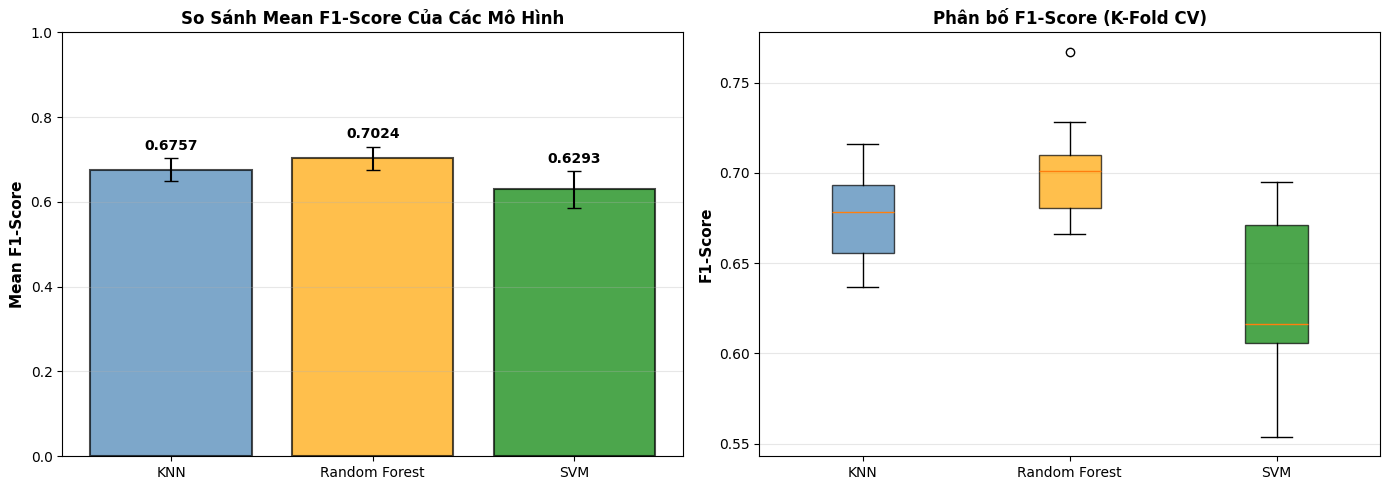


  Trực quan hóa kết quả hoàn tất


In [18]:
# Trực quan hóa kết quả so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - So sánh Mean F1-Score
models_list = list(cv_results.keys())
mean_scores = [cv_results[m]['mean_f1'] for m in models_list]
std_scores = [cv_results[m]['std_f1'] for m in models_list]
colors_bar = ['steelblue', 'orange', 'green']

axes[0].bar(models_list, mean_scores, yerr=std_scores, capsize=5, 
            color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean F1-Score', fontsize=11, fontweight='bold')
axes[0].set_title('So Sánh Mean F1-Score Của Các Mô Hình', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(mean_scores):
    axes[0].text(i, v + std_scores[i] + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Box plot - Phân bố F1-Scores
f1_data = [cv_results[m]['f1_scores'] for m in models_list]
bp = axes[1].boxplot(f1_data, labels=models_list, patch_artist=True)

for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1].set_title('Phân bố F1-Score (K-Fold CV)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n  Trực quan hóa kết quả hoàn tất")

## 4. Gom Cụm (Clustering)

### 4.1 Chuẩn bị dữ liệu cho Clustering

In [201]:
# Loại bỏ cột nhãn (unsupervised learning)
X_clustering = X_scaled.copy()
y_true = y.values  # Lưu nhãn gốc để đánh giá

print(f"  Dữ liệu cho clustering: {X_clustering.shape[0]} mẫu, {X_clustering.shape[1]} đặc trưng")
print(f"  Nhãn gốc được lưu để đánh giá kết quả")

  Dữ liệu cho clustering: 1599 mẫu, 11 đặc trưng
  Nhãn gốc được lưu để đánh giá kết quả


### 4.2 K-Means Clustering

In [202]:
# Xác định số cụm tối ưu bằng Elbow Method
inertias = []
silhouette_scores_km = []
k_range = range(2, 11)
#hfhfhfh
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertias.append(kmeans.inertia_)
    silhouette_scores_km.append(silhouette_score(X_clustering, kmeans.labels_))

print("  Tìm số cụm tối ưu cho K-Means")

  Tìm số cụm tối ưu cho K-Means


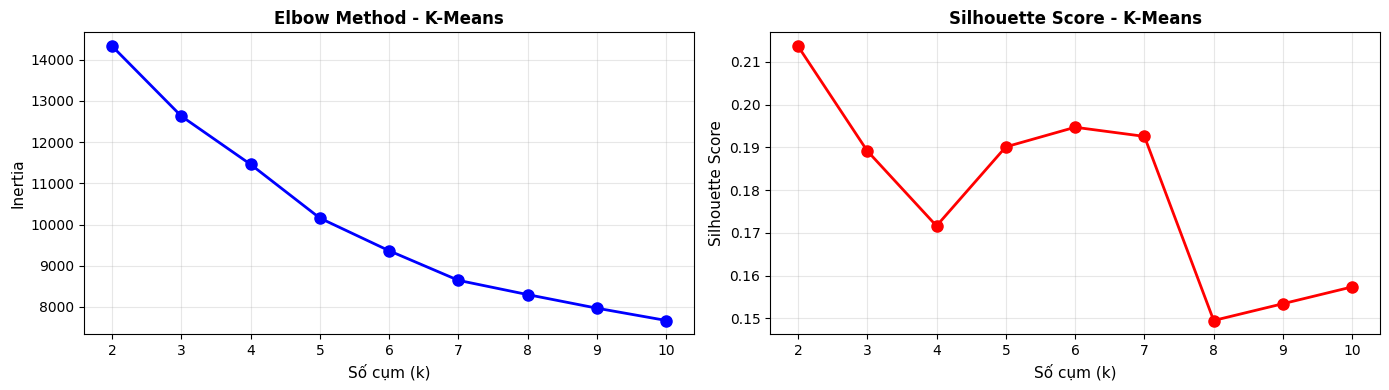


  Số cụm được chọn: 6 (matches số lớp trong dữ liệu)


In [203]:
# Visualize Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Số cụm (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method - K-Means', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores_km, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Số cụm (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score - K-Means', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Chọn số cụm tối ưu (dựa trên số lớp = 6)
optimal_k = len(np.unique(y_true))
print(f"\n  Số cụm được chọn: {optimal_k} (matches số lớp trong dữ liệu)")

In [204]:
# Huấn luyện K-Means với số cụm tối ưu
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustering)

print(f"\n  K-Means clustering hoàn tất")
print(f"Silhouette Score: {silhouette_score(X_clustering, kmeans_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_clustering, kmeans_labels):.4f}")


  K-Means clustering hoàn tất
Silhouette Score: 0.1947
Davies-Bouldin Score: 1.3984


### 4.3 DBSCAN Clustering

In [205]:
# Tìm epsilon tối ưu bằng k-distance graph
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_clustering)
distances, indices = neighbors_fit.kneighbors(X_clustering)
distances = np.sort(distances[:, -1], axis=0)

print("  Tính k-distance graph cho DBSCAN")

  Tính k-distance graph cho DBSCAN


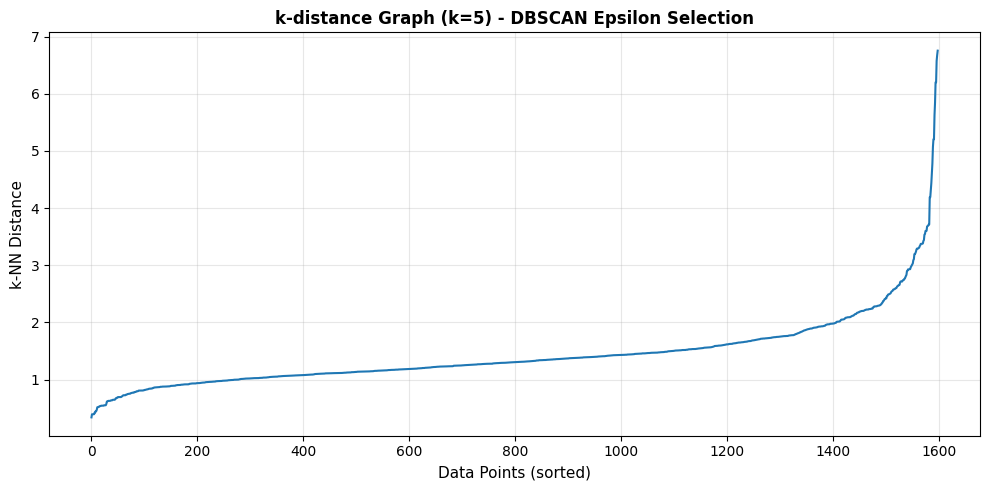


  Epsilon được chọn: 2.7


In [206]:
# Visualize k-distance graph
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points (sorted)', fontsize=11)
plt.ylabel('k-NN Distance', fontsize=11)
plt.title('k-distance Graph (k=5) - DBSCAN Epsilon Selection', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chọn epsilon (thường ở "elbow" của k-distance graph)
epsilon = 2.7  # Có thể điều chỉnh dựa trên biểu đồ
print(f"\n  Epsilon được chọn: {epsilon}")

In [207]:
# Huấn luyện DBSCAN
dbscan = DBSCAN(eps=epsilon, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_clustering)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\n  DBSCAN clustering hoàn tất")
print(f"Số cụm tìm được: {n_clusters_dbscan}")
print(f"Số điểm noise (label=-1): {n_noise}")

if n_clusters_dbscan > 1 and n_noise < len(X_clustering) - 1:
    print(f"Silhouette Score: {silhouette_score(X_clustering, dbscan_labels):.4f}")
    if n_noise == 0:
        print(f"Davies-Bouldin Score: {davies_bouldin_score(X_clustering, dbscan_labels):.4f}")


  DBSCAN clustering hoàn tất
Số cụm tìm được: 2
Số điểm noise (label=-1): 48
Silhouette Score: 0.4677


### 4.4 Đánh Giá Kết Quả Gom Cụm

In [208]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Tính các độ đo đánh giá so với nhãn gốc
# (Loại bỏ noise points có label=-1 cho DBSCAN)
dbscan_mask = dbscan_labels != -1
y_true_filtered = y_true[dbscan_mask]
dbscan_labels_filtered = dbscan_labels[dbscan_mask]

# **K-Means evaluation**
kmeans_homogeneity = homogeneity_score(y_true, kmeans_labels)
kmeans_completeness = completeness_score(y_true, kmeans_labels)
kmeans_v_measure = v_measure_score(y_true, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y_true, kmeans_labels)

# **DBSCAN evaluation** (chỉ những không phải noise)
if len(y_true_filtered) > 0 and len(np.unique(dbscan_labels_filtered)) > 1:
    dbscan_homogeneity = homogeneity_score(y_true_filtered, dbscan_labels_filtered)
    dbscan_completeness = completeness_score(y_true_filtered, dbscan_labels_filtered)
    dbscan_v_measure = v_measure_score(y_true_filtered, dbscan_labels_filtered)
    dbscan_ari = adjusted_rand_score(y_true_filtered, dbscan_labels_filtered)
    dbscan_nmi = normalized_mutual_info_score(y_true_filtered, dbscan_labels_filtered)
else:
    dbscan_homogeneity = dbscan_completeness = dbscan_v_measure = dbscan_ari = dbscan_nmi = 0

# Tạo bảng đánh giá
clustering_eval_df = pd.DataFrame({
    'Độ đo': ['Homogeneity', 'Completeness', 'V-Measure', 'Adjusted Rand Index', 'Normalized Mutual Info'],
    'K-Means': [kmeans_homogeneity, kmeans_completeness, kmeans_v_measure, kmeans_ari, kmeans_nmi],
    'DBSCAN': [dbscan_homogeneity, dbscan_completeness, dbscan_v_measure, dbscan_ari, dbscan_nmi]
})
print(clustering_eval_df.to_string(index=False))


                 Độ đo  K-Means    DBSCAN
           Homogeneity 0.104954  0.001483
          Completeness 0.082762  0.030618
             V-Measure 0.092546  0.002829
   Adjusted Rand Index 0.061945 -0.002716
Normalized Mutual Info 0.092546  0.002829


## Sua doi muc 4

### k-mean

In [209]:
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 1. Đọc và chuẩn bị dữ liệu
df = pd.read_csv('data/winequality-red.csv')
X = df.drop(columns=['quality'])
y_true = df['quality']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Tìm K và chạy K-Means
print("=== CHẠY K-MEANS VÀ TÌM GIÁ TRỊ K TỐI ƯU ===")
best_k = -1
best_kmeans_ari = -1

# Thử nghiệm số lượng cụm k từ 2 đến 9
for k in range(2, 10):
    start_time = time.time()
    
    # Sử dụng n_init=10 để chạy 10 lần với khởi tạo K-Means++ nhằm tránh cực tiểu địa phương
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_scaled)
    
    exec_time = time.time() - start_time
    
    # Tính toán độ đo Adjusted Rand Index (ARI) và Silhouette Score (Sil)
    ari = adjusted_rand_score(y_true, labels_kmeans)
    sil = silhouette_score(X_scaled, labels_kmeans)
    
    print(f"k={k} -> ARI={ari:.4f}, Sil={sil:.4f}, time={exec_time:.4f}s")
    
    # Lưu lại kết quả tốt nhất dựa trên ARI
    if ari > best_kmeans_ari:
        best_kmeans_ari = ari
        best_k = k

print(f"\n=> KẾT LUẬN K-MEANS: K tối ưu là {best_k} với ARI = {best_kmeans_ari:.4f}")

=== CHẠY K-MEANS VÀ TÌM GIÁ TRỊ K TỐI ƯU ===
k=2 -> ARI=0.0433, Sil=0.2137, time=0.0578s
k=3 -> ARI=0.0292, Sil=0.1892, time=0.0546s
k=4 -> ARI=0.0629, Sil=0.1716, time=0.0539s
k=5 -> ARI=0.0645, Sil=0.1901, time=0.0626s
k=6 -> ARI=0.0619, Sil=0.1947, time=0.0684s
k=7 -> ARI=0.0712, Sil=0.1926, time=0.0723s
k=8 -> ARI=0.0544, Sil=0.1495, time=0.0645s
k=9 -> ARI=0.0506, Sil=0.1534, time=0.0689s

=> KẾT LUẬN K-MEANS: K tối ưu là 7 với ARI = 0.0712


### DB SCAN

In [210]:
from sklearn.cluster import DBSCAN

print("=== CHẠY DBSCAN VÀ TÌM THAM SỐ TỐI ƯU ===")
# Tập hợp các giá trị thử nghiệm cho bán kính (eps) và số điểm tối thiểu (min_samples)
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
ms_values = [3, 5, 8, 10]

best_dbscan_ari = -1
best_eps = -1
best_ms = -1

for eps in eps_values:
    for ms in ms_values:
        start_time = time.time()
        
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels_dbscan = dbscan.fit_predict(X_scaled)
        
        exec_time = time.time() - start_time
        
        # Đếm số lượng cụm sinh ra (loại bỏ nhãn -1 là dữ liệu nhiễu)
        n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
        
        # Chỉ tính Silhouette Score khi có từ 2 cụm trở lên
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels_dbscan)
            ari = adjusted_rand_score(y_true, labels_dbscan)
        else:
            sil = -1.0
            ari = adjusted_rand_score(y_true, labels_dbscan)
            
        print(f"eps={eps:.2f}, ms={ms:<2} -> clusters={n_clusters:<2}, ARI={ari:.4f}, Sil={sil:.4f}, time={exec_time:.4f}s")
        
        if ari > best_dbscan_ari:
            best_dbscan_ari = ari
            best_eps = eps
            best_ms = ms

print(f"\n=> KẾT LUẬN DBSCAN: Tham số tối ưu là eps={best_eps:.2f}, min_samples={best_ms} với ARI = {best_dbscan_ari:.4f}")

=== CHẠY DBSCAN VÀ TÌM THAM SỐ TỐI ƯU ===
eps=0.50, ms=3  -> clusters=33, ARI=-0.0065, Sil=-0.4114, time=0.0345s
eps=0.50, ms=5  -> clusters=3 , ARI=-0.0044, Sil=-0.2505, time=0.0233s
eps=0.50, ms=8  -> clusters=1 , ARI=-0.0027, Sil=-1.0000, time=0.0206s
eps=0.50, ms=10 -> clusters=1 , ARI=-0.0025, Sil=-1.0000, time=0.0224s
eps=1.00, ms=3  -> clusters=81, ARI=-0.0166, Sil=-0.2519, time=0.0368s
eps=1.00, ms=5  -> clusters=24, ARI=-0.0172, Sil=-0.3178, time=0.0356s
eps=1.00, ms=8  -> clusters=8 , ARI=-0.0267, Sil=-0.2476, time=0.0333s
eps=1.00, ms=10 -> clusters=5 , ARI=-0.0265, Sil=-0.2162, time=0.0335s
eps=1.50, ms=3  -> clusters=19, ARI=0.0164, Sil=-0.2059, time=0.0394s
eps=1.50, ms=5  -> clusters=3 , ARI=0.0177, Sil=0.0981, time=0.0376s
eps=1.50, ms=8  -> clusters=2 , ARI=0.0229, Sil=0.0451, time=0.0422s
eps=1.50, ms=10 -> clusters=1 , ARI=0.0230, Sil=-1.0000, time=0.0370s
eps=2.00, ms=3  -> clusters=7 , ARI=0.0058, Sil=0.1871, time=0.0433s
eps=2.00, ms=5  -> clusters=3 , ARI=0.0068,

### danh gia

In [211]:
# Tổng hợp và so sánh kết quả
print("=== BẢNG SO SÁNH HIỆU NĂNG GOM CỤM ===")
print("-" * 75)
print(f"{'Thuật toán':<15} | {'Cấu hình tham số tối ưu':<35} | {'Chỉ số ARI':<15}")
print("-" * 75)
print(f"{'K-Means':<15} | k = {best_k:<31} | {best_kmeans_ari:.4f}")
print(f"{'DBSCAN':<15} | eps = {best_eps}, min_samples = {best_ms:<17} | {best_dbscan_ari:.4f}")
print("-" * 75)

# Đưa ra nhận xét tự động dựa trên chỉ số ARI
if best_kmeans_ari > best_dbscan_ari:
    print("\nNhận xét: K-Means cho kết quả gom cụm tương đồng với nhãn thực tế tốt hơn DBSCAN trên tập dữ liệu này.")
elif best_dbscan_ari > best_kmeans_ari:
    print("\nNhận xét: DBSCAN cho kết quả gom cụm tương đồng với nhãn thực tế tốt hơn K-Means trên tập dữ liệu này.")
else:
    print("\nNhận xét: Cả hai thuật toán đều cho kết quả tương đương nhau.")

=== BẢNG SO SÁNH HIỆU NĂNG GOM CỤM ===
---------------------------------------------------------------------------
Thuật toán      | Cấu hình tham số tối ưu             | Chỉ số ARI     
---------------------------------------------------------------------------
K-Means         | k = 7                               | 0.0712
DBSCAN          | eps = 1.5, min_samples = 10                | 0.0230
---------------------------------------------------------------------------

Nhận xét: K-Means cho kết quả gom cụm tương đồng với nhãn thực tế tốt hơn DBSCAN trên tập dữ liệu này.


## 5. Tóm Tắt Kết Quả

In [200]:
print("\n" + "="*80)
print("TÓM TẮT KẾT QUẢ PHÂN TÍCH DỮ LIỆU RƯỢU VANG")
print("="*80)

print("\n1. THÔNG TIN DỮ LIỆU:")
print(f"   - Số mẫu: {df.shape[0]}")
print(f"   - Số đặc trưng: {df.shape[1] - 1}")  
print(f"   - Số lớp: {len(np.unique(y_true))}")
print(f"   - Phân bố nhãn: {dict(zip(sorted(np.unique(y_true)), [len(y_true[y_true==i]) for i in sorted(np.unique(y_true))]))}")  

print("\n2. TRỰC QUAN HÓA:")
print(f"   - Phương pháp: PCA (Dimensionality Reduction)")
print(f"   - Chiều gốc: {X_scaled.shape[1]}")
print(f"   - Chiều sau giảm: 2")
print(f"   - Variance giải thích: {sum(pca.explained_variance_ratio_):.2%}")

print("\n3. HUẤN LUYỆN MÔ HÌNH (K-Fold CV, k=10):")
for idx, row in comparison_df.iterrows():
    print(f"   {idx+1}. {row['Model']}: F1-Score = {row['Mean F1-Score']:.4f} ± {row['Std F1-Score']:.4f}")

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n   ➜ Mô hình tốt nhất: {best_model_name}")

print("\n4. GOM CỤM:")
print(f"   K-Means (k={optimal_k}):")
print(f"      - Silhouette Score: {silhouette_score(X_clustering, kmeans_labels):.4f}")
print(f"      - Homogeneity: {kmeans_homogeneity:.4f}")
print(f"      - V-Measure: {kmeans_v_measure:.4f}")

print(f"\n   DBSCAN (eps={epsilon}, min_samples=5):")
print(f"      - Số cụm: {n_clusters_dbscan}")
print(f"      - Điểm noise: {n_noise}")
if n_clusters_dbscan > 1 and n_noise < len(X_clustering) - 1:
    print(f"      - Silhouette Score: {silhouette_score(X_clustering, dbscan_labels):.4f}")
    print(f"      - Homogeneity: {dbscan_homogeneity:.4f}")
    print(f"      - V-Measure: {dbscan_v_measure:.4f}")

print("\n" + "="*80)
print("Các file được lưu:")
print("   - model_comparison.csv")
print("   - clustering_evaluation.csv")
print("="*80)


TÓM TẮT KẾT QUẢ PHÂN TÍCH DỮ LIỆU RƯỢU VANG

1. THÔNG TIN DỮ LIỆU:
   - Số mẫu: 1599
   - Số đặc trưng: 11
   - Số lớp: 6
   - Phân bố nhãn: {np.int64(3): 10, np.int64(4): 53, np.int64(5): 681, np.int64(6): 638, np.int64(7): 199, np.int64(8): 18}

2. TRỰC QUAN HÓA:
   - Phương pháp: PCA (Dimensionality Reduction)
   - Chiều gốc: 11
   - Chiều sau giảm: 2
   - Variance giải thích: 45.68%

3. HUẤN LUYỆN MÔ HÌNH (K-Fold CV, k=10):
   1. Random Forest: F1-Score = 0.7024 ± 0.0281
   2. KNN: F1-Score = 0.6757 ± 0.0272
   3. SVM: F1-Score = 0.6293 ± 0.0429

   ➜ Mô hình tốt nhất: Random Forest

4. GOM CỤM:
   K-Means (k=6):
      - Silhouette Score: 0.1947
      - Homogeneity: 0.1050
      - V-Measure: 0.0925

   DBSCAN (eps=2.7, min_samples=5):
      - Số cụm: 2
      - Điểm noise: 48
      - Silhouette Score: 0.4677
      - Homogeneity: 0.0015
      - V-Measure: 0.0028

Các file được lưu:
   - model_comparison.csv
   - clustering_evaluation.csv
